<a href="https://colab.research.google.com/github/denverkim/ALGORITHM/blob/main/ALGORITHM_LAB11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

train = pd.read_excel('/content/logit_trian.xlsx')
test = pd.read_excel('/content/logit_trian.xlsx',sheet_name='test')

In [15]:
# 독립변수, 종속변수 지정
train.head()
y_train = train.admitted
x_train = train[['gmat', 'gpa', 'work_experience']]
y_test = test.admitted
x_test = test[['gmat', 'gpa', 'work_experience']]

In [16]:
# Build a logistic regression model. 예측모델 구축
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [17]:
model.coef_ # 기울기

array([[0.02324794, 0.7728536 , 0.99548198]])

In [18]:
model.intercept_ # y절편

array([-21.48179059])

In [ ]:
# admitted = -21.48179059 + 0.02324794 * gmat + 0.7728536 * gpa + 0.99548198 * work_experience

In [19]:
# Check the accuracy score of the model. 성능평가
model.score(x_test, y_test) # 정확도

1.0

In [20]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred) # 정확도

1.0

In [25]:
# 10겹 교차검증을 사용하여 모델을 평가
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x_train, y_train, cv=10)
scores.mean(), scores.std()

(np.float64(0.9), np.float64(0.16583123951777))

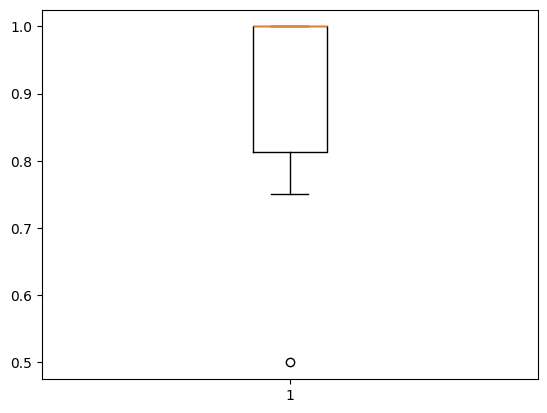

In [29]:
# 교차검증 결과 시각화
import matplotlib.pyplot as plt
plt.boxplot(scores)
plt.show()

[[2 0]
 [0 3]]


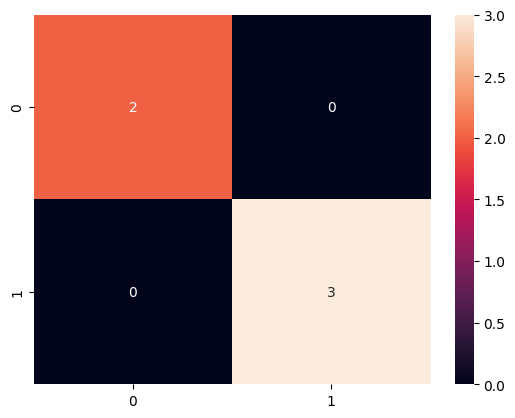

In [31]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test)
print(confusion_matrix(y_test, y_pred))

import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

In [32]:
# 분류리포트
from sklearn.metrics import classification_report
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



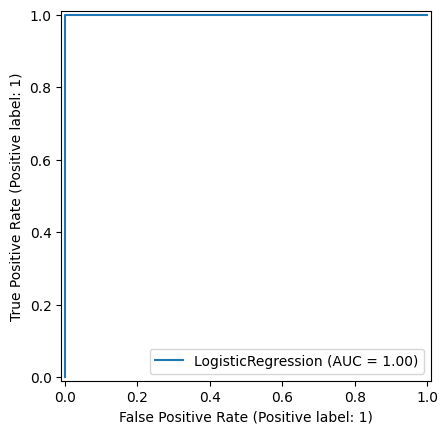

In [33]:
# ROC커브
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, x_test, y_test)

In [ ]:

§Predict with test data. 테스트 데이터를 가지고 예측